# Accelerated homology computation and plotting

Homology is a mathematical tool to study the shape of point clouds, networks, manifolds, hypergraphs, and other interesting data types; it is used extensively in the field of [topological data analysis](https://en.wikipedia.org/wiki/Topological_data_analysis). Computing homology can take a lot of time and memory, even for hypergraphs of moderate size. To address this issue, HNX offers a module to compute homology using Open Applied Topology (OAT) as a backend. 

- This can dramatically reduce the time and memory cost of computation.
- Outputs are formatted as human-readable dataframes for cycle representatives, betti numbers, etc.
- Plotting utilities for 2d and 3d visualization are provided.

**NB: Rational Coefficients** The OAT solver computes homology only over the rationals, currently; compare with the native HypernetX homology solver, which computes homology over the two-element field.


## Scaling

In the following example we consider a sequence of hypergraphs on node set `0 .. 14`. For each graph we sample somewhere between one and six random subsets of size 10, and these subsets become the edges of the graph. As we can see, the OAT-backed homology solver helps immensely with scaling!

In [1]:
import hypernetx as hnx
import time
import pandas as pd
from random import sample
from hypernetx.algorithms import oat_accelerator

num_edges = []
times_hnx = []
times_oat = []

for i in range(1, 7):

    H = hnx.Hypergraph([sorted(sample(range(15), 10)) for _ in range(i)])
    num_edges.append(i)

    # Compute mod 2 homology using Pure Python
    start = time.time()
    hnx.hypergraph_homology_basis(H, k=[1,2])
    end = time.time()
    times_hnx.append(end - start)

    # Compute homology over the rational numbers using OAT Backend
    start = time.time()
    oat_accelerator.get_homology(H, max_homology_dimension=2)
    end = time.time()
    times_oat.append(end - start)  


print("")
print("Execution time in seconds:")
print("")
df = pd.DataFrame({"No. Hyperedges": num_edges, "Mod 2 Homology (Pure Python)": times_hnx, "Rational Homology (OAT Backend)": times_oat})  
display(df)



Execution time in seconds:



,No. Hyperedges,Mod 2 Homology (Pure Python),Rational Homology (OAT Backend)
0,1,0.053818,0.000820
1,2,0.221431,0.001026
2,3,0.688433,0.001045
3,4,3.232332,0.001218
4,5,4.945099,0.001265
5,6,8.175391,0.001240


## Outputs

Let's explore the outputs of a homology computation. First we'll define a hypergraph:

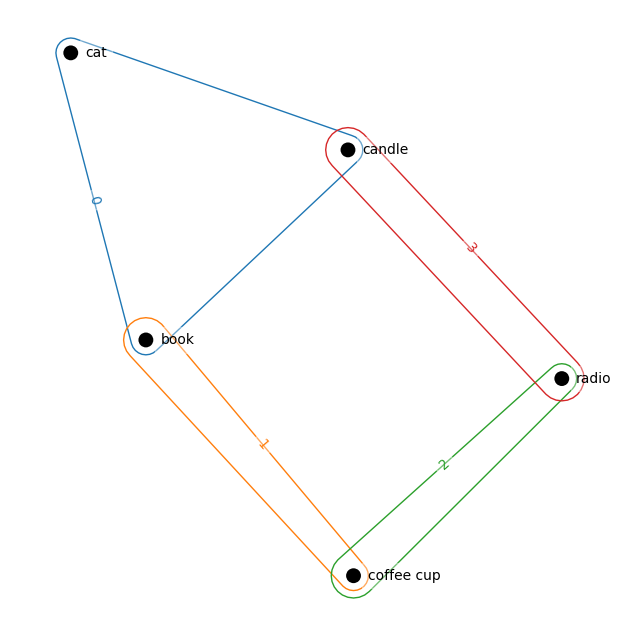

In [2]:
import hypernetx as hnx 
H   =   hnx.Hypergraph([['book','candle','cat'],['book','coffee cup'],['coffee cup','radio'], ['radio', 'candle']])
hnx.draw(H)    

Now let's compute its homology.

In [3]:
# This method will compute homology with rational coefficients in dimensions 0, 1, and 2.
homology = oat_accelerator.get_homology( H, max_homology_dimension=2 )

We can inspect the cycle representatives using the `cycle_representatives` method. The resulting data frame has one row for each basis vector in homology. The `dimension` column contains the dimension of the corresponding homology class. The `cycle representative` column contains a corresponding cycle representative.

In [4]:
cycle_representatives       =   homology.cycle_representatives()
display(cycle_representatives)

,dimension,cycle representative
0,0,simplex coefficient 0 [book] 1
1,1,simplex coefficient 0 [coffee ...


Let's inspect a cycle representative for the 1-dimensional homology class. This representative is formatted as a data frame listing the simplices associated with the cycle representative, and the associated coefficients.

In [5]:
cycle_representative        =   cycle_representatives["cycle representative"][1]
display(cycle_representative)

,simplex,coefficient
0,"[coffee cup, radio]",1
1,"[candle, radio]",-1
2,"[book, coffee cup]",1
3,"[book, candle]",-1


There are two optional keyword arguments for the `cycle_representatives` method:
- `numeric_node_labels=True` will replace node labels in each simplex with integers
- `count_simplices_per_cycle=True` will add a column to the dataframe which reports the number of simplices in each cycle representative

In [6]:
cycle_representatives_int_labels = homology.cycle_representatives(numeric_node_labels=True, count_simplices_per_cycle=True)
display(cycle_representatives_int_labels)
display(cycle_representatives_int_labels["cycle representative"][1])

,dimension,cycle representative,nnz
0,0,simplex coefficient 0 [0] 1,1
1,1,"simplex coefficient 0 [3, 4] 1 1 ...",4


,simplex,coefficient
0,"[3, 4]",1
1,"[1, 4]",-1
2,"[0, 3]",1
3,"[0, 1]",-1


Finally, the `homology` object offers a method to compute betti numbers directly:

In [7]:
display( homology.betti_numbers() )

,Betti number
homology dimension,
0,1
1,1
2,0


## Plotting

Finally, HypernetX offers a variety of plotting functions compatible with the output of the OAT homology backend.

### First visualize the hypergraph

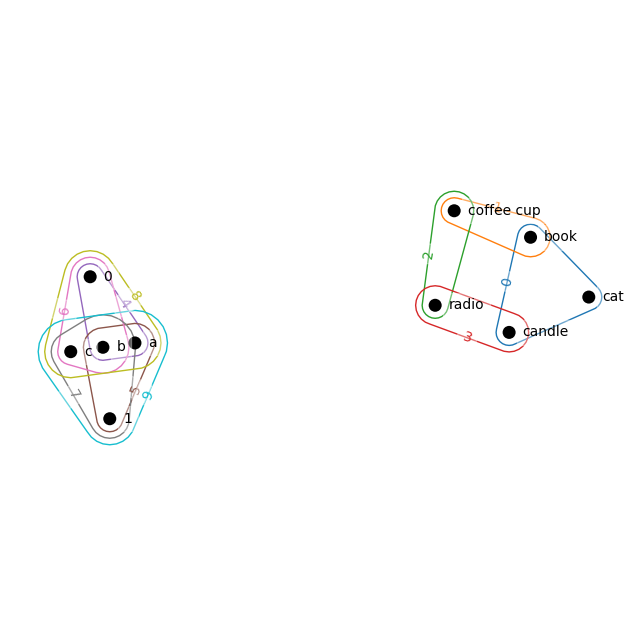

In [8]:
# DEFINE A HYPERGRAPH WITH NONTRIVIAL HOMOLOGY IN DIMENSIONS 1 AND 2
#
# This hypergraph is a disjoint union of two separate hypergraphs, one 
# with the homology of a circle, the other with the homology of a sphere.

component_a     =   [['book','candle','cat'],['book','coffee cup'],['coffee cup','radio'], ['radio', 'candle']]
component_b     =   []
for edge in [['a','b'], ['b','c'],['a','c']]:
    component_b.append( edge + ['0'] )
    component_b.append( edge + ['1'] )  

H               =   hnx.Hypergraph(component_a + component_b)
hnx.draw(H)    

### Now plot several cycle representatives

In [9]:
# COMPUTE HOMOLOGY

homology        =   oat_accelerator.get_homology(H, max_homology_dimension=2)
display(homology.cycle_representatives())

,dimension,cycle representative
0,0,simplex coefficient 0 [book] 1
1,0,simplex coefficient 0 [0] 1
2,1,simplex coefficient 0 [coffee ...
3,2,"simplex coefficient 0 [1, b, c] ..."


In [10]:
# PLOT CYCLE REPRESENTATIVES WITH VARIOUS CUSTOMIZATIONS

import plotly.graph_objects as go

fig_1   =    oat_accelerator.plot_cycle_representative(
                homology.cycle_representatives()["cycle representative"][2], 
                coordinate_dictionary = None, 
                embedding_dimension = 3
            )   
fig_2   =    oat_accelerator.plot_cycle_representative(
                homology.cycle_representatives(numeric_node_labels=True)["cycle representative"][2], 
                coordinate_dictionary = None, 
                embedding_dimension = 3
            )    
fig_3   =   oat_accelerator.plot_cycle_representative(
                homology.cycle_representatives()["cycle representative"][2], 
                coordinate_dictionary = None, 
                embedding_dimension = 2
            )    
fig_4   =   oat_accelerator.plot_cycle_representative(
                homology.cycle_representatives()["cycle representative"][2], 
                coordinate_dictionary = {"radio": [-1,-1], "coffee cup": [-1,1], "book": [1,1], "candle": [1,-1]}, 
                embedding_dimension = 2
            )   
fig_5   =   oat_accelerator.plot_cycle_representative(
                homology.cycle_representatives()["cycle representative"][2], 
                coordinate_dictionary = {"radio": [-1,-1,0], "coffee cup": [-1,1,0], "book": [1,1,0], "candle": [1,-1,1]}, 
                embedding_dimension = 3
            )    
fig_6   =   oat_accelerator.plot_cycle_representative(
                homology.cycle_representatives()["cycle representative"][3], 
                coordinate_dictionary = None, 
                embedding_dimension = 3
            )  
fig_7   =   oat_accelerator.plot_cycle_representative(
                homology.cycle_representatives()["cycle representative"][3], 
                coordinate_dictionary = {"a":[1,0,0], "b":[0,1,0], "c":[0,0,1], "0":[0,0,0], "1":[1,1,1] }, 
                embedding_dimension = 3
            )  

# Make each edge in Figure 4 blue
for trace in fig_4.data:
    if isinstance(trace, go.Scatter):
        trace.update(line = dict(color="blue") )

# Update the layout for Figure 4
fig_4.update_layout(
    title="Stretched x-axis, custom node positions, and blue edges",
    width=1000,
    height=500,
)             

# Color each triangle in Figure 6 red
for trace in fig_6.data:
    if isinstance(trace, go.Mesh3d):
        trace.update(color="red")

# Update the layout for Figure 7
fig_7.update_layout(
    title="Custom node positions, custom z-axis limits",
    width=1000,
    height=500,
    scene = dict(
        # aspectratio=go.layout.scene.Aspectratio(x=1, y=1, z=1), # controls zoom
        xaxis = dict(range=[ 0, 1],), # x axis limits
        yaxis = dict(range=[ 0, 1],), # y axis limits
        zaxis = dict(range=[-1, 3],), # z axis limits        
    ),
)          
     
# Display plots
fig_1.show()
fig_2.show()
fig_3.show()
fig_4.show()
fig_5.show()
fig_6.show()
fig_7.show()